<a href="https://colab.research.google.com/github/oluwafemi244/facility-maintenance-energy-decision-support/blob/main/notebooks/02_failure_risk_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline Failure-Risk Modeling

## Facility Maintenance and Energy Decision-Support Framework

This notebook develops and evaluates preliminary failure risk models for the maintenance workstream of the Facility Maintenance and Energy Decision Support Framework.

The objective is to determine whether selected operating and condition variables in the AI4I 2020 Predictive Maintenance Dataset can be used to estimate the probability of machine failure.

The models developed here are baseline proof-of-concept models. They are not presented as validated operational maintenance systems.

The AI4I dataset is synthetic, and additional validation using other datasets and technical evidence will be required before any model is considered suitable for practical facility use.

Because machine failures represent only a small percentage of the dataset, model performance will not be evaluated using accuracy alone. Precision, recall, F1 score, ROC-AUC, average precision, balanced accuracy, confusion matrices, and precision-recall behavior will also be examined.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

In [2]:
data_url = (
    "https://raw.githubusercontent.com/"
    "oluwafemi244/facility-maintenance-energy-decision-support/"
    "main/data/ai4i2020.csv"
)

df = pd.read_csv(data_url)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 10,000
Columns: 14


## Predictor Selection

The preliminary model uses operating and condition variables that would be available before the failure outcome is known.

The candidate predictors are:

- product type;
- air temperature;
- process temperature;
- rotational speed;
- torque; and
- tool wear.

`Machine failure` is the prediction target.

The individual failure-mode indicators (`TWF`, `HDF`, `PWF`, `OSF`, and `RNF`) are excluded from the predictor set because they directly describe failure events and could introduce target leakage.

`UDI` and `Product ID` are also excluded because they primarily serve as observation and product identifiers rather than operating-condition measurements.

In [3]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

categorical_features = ["Type"]

features = numeric_features + categorical_features
target = "Machine failure"

X = df[features].copy()
y = df[target].copy()

print("Predictor variables:")
for feature in features:
    print("-", feature)

print("\nTarget:", target)

print("\nTarget distribution:")
print(y.value_counts())

print(f"\nFailure rate: {y.mean() * 100:.2f}%")

Predictor variables:
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]
- Type

Target: Machine failure

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training observations: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")

print(f"\nTraining failure rate: {y_train.mean() * 100:.2f}%")
print(f"Test failure rate: {y_test.mean() * 100:.2f}%")

Training observations: 8,000
Test observations: 2,000

Training failure rate: 3.39%
Test failure rate: 3.40%


In [6]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [7]:
models = {
    "Dummy Baseline": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", DummyClassifier(
            strategy="most_frequent"
        ))
    ]),

    "Logistic Regression": Pipeline([
        ("preprocessor", linear_preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

In [8]:
results = []
trained_models = {}

for name, model in models.items():

    print("=" * 70)
    print(name)
    print("=" * 70)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
        avg_precision = average_precision_score(y_test, y_prob)
    else:
        roc_auc = np.nan
        avg_precision = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Average Precision": avg_precision
    })

    trained_models[name] = model

    print(classification_report(
        y_test,
        y_pred,
        digits=3,
        zero_division=0
    ))

results_df = pd.DataFrame(results)

results_df

Dummy Baseline
              precision    recall  f1-score   support

           0      0.966     1.000     0.983      1932
           1      0.000     0.000     0.000        68

    accuracy                          0.966      2000
   macro avg      0.483     0.500     0.491      2000
weighted avg      0.933     0.966     0.949      2000

Logistic Regression
              precision    recall  f1-score   support

           0      0.993     0.825     0.901      1932
           1      0.142     0.824     0.242        68

    accuracy                          0.825      2000
   macro avg      0.567     0.824     0.571      2000
weighted avg      0.964     0.825     0.878      2000

Decision Tree
              precision    recall  f1-score   support

           0      0.996     0.931     0.962      1932
           1      0.309     0.882     0.458        68

    accuracy                          0.929      2000
   macro avg      0.652     0.906     0.710      2000
weighted avg      0.972  

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Dummy Baseline,0.9660,0.500000,0.000000,0.000000,0.000000,0.500000,0.034000
1,Logistic Regression,0.8245,0.824032,0.141772,0.823529,0.241901,0.906954,0.381762
2,Decision Tree,0.9290,0.906497,0.309278,0.882353,0.458015,0.911068,0.590063
3,Random Forest,0.9800,0.727165,0.911765,0.455882,0.607843,0.963582,0.776209


In [9]:
formatted_results = results_df.copy()

metric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC",
    "Average Precision"
]

formatted_results[metric_columns] = (
    formatted_results[metric_columns]
    .round(4)
)

formatted_results

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Dummy Baseline,0.9660,0.5000,0.0000,0.0000,0.0000,0.5000,0.0340
1,Logistic Regression,0.8245,0.8240,0.1418,0.8235,0.2419,0.9070,0.3818
2,Decision Tree,0.9290,0.9065,0.3093,0.8824,0.4580,0.9111,0.5901
3,Random Forest,0.9800,0.7272,0.9118,0.4559,0.6078,0.9636,0.7762


## Baseline Interpretation

Because approximately 96.61% of the observations represent non failures, a model that predicts "no failure" for every observation can achieve high ordinary accuracy while providing no useful ability to identify actual failures.

For this reason, ordinary accuracy is not sufficient to evaluate the models.

Greater attention is given to:

- **Recall:** the proportion of actual failures detected by the model;
- **Precision:** the proportion of predicted failures that are actually failures;
- **F1 score:** the balance between precision and recall;
- **Balanced accuracy:** performance across both failure and non-failure classes;
- **ROC-AUC:** the model's ability to discriminate between classes across decision thresholds; and
- **Average precision:** performance of the precision-recall relationship, which is especially useful when failures are uncommon.

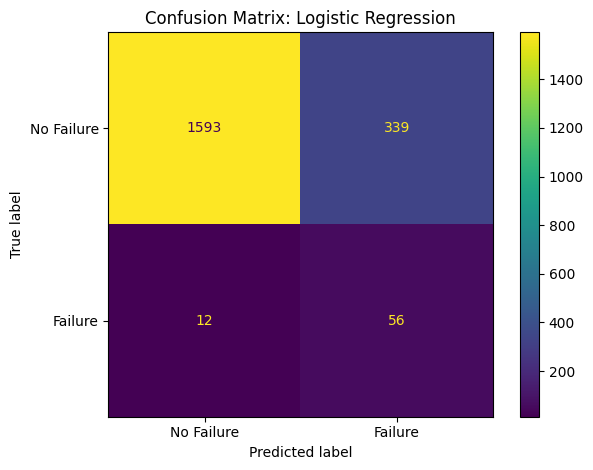

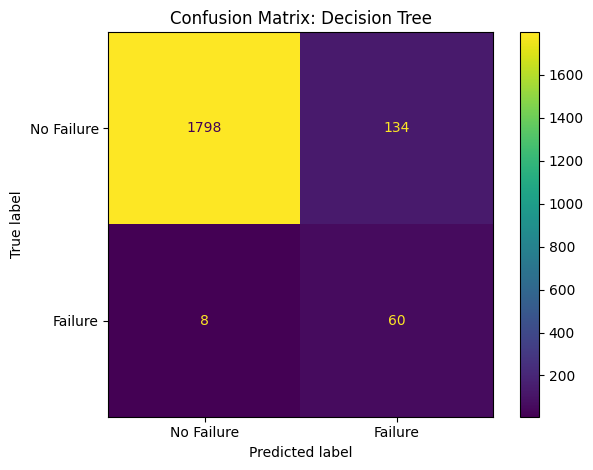

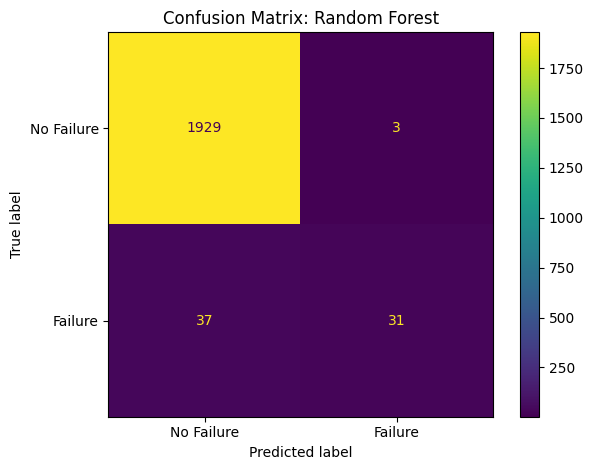

In [10]:
for name in [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]:
    model = trained_models[name]

    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No Failure", "Failure"]
    )

    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

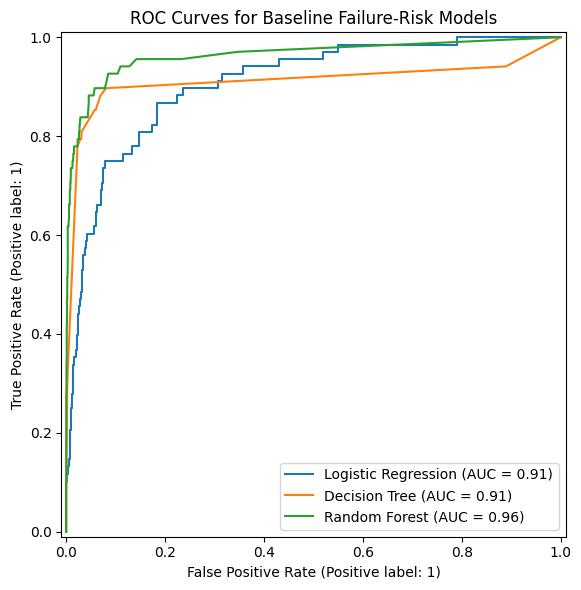

In [11]:
plt.figure(figsize=(8, 6))

ax = plt.gca()

for name in [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]:
    model = trained_models[name]

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax
    )

plt.title("ROC Curves for Baseline Failure-Risk Models")
plt.tight_layout()
plt.show()

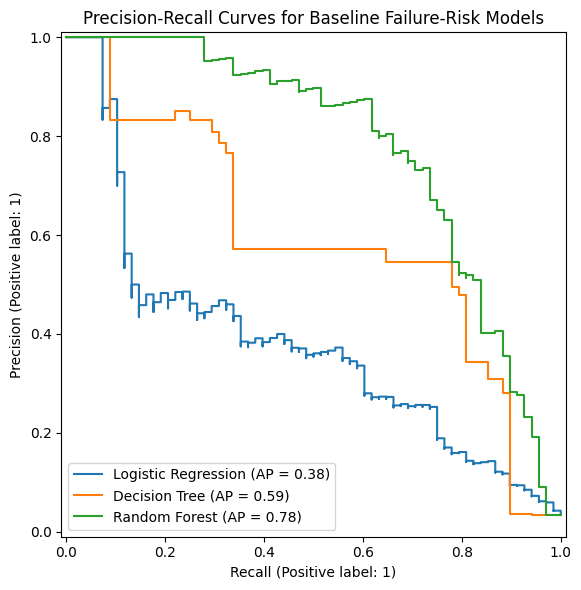

In [12]:
plt.figure(figsize=(8, 6))

ax = plt.gca()

for name in [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]:
    model = trained_models[name]

    PrecisionRecallDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax
    )

plt.title("Precision-Recall Curves for Baseline Failure-Risk Models")
plt.tight_layout()
plt.show()

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

cv_results = []

for name in [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]:

    scores = cross_validate(
        models[name],
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Balanced Accuracy Mean": scores["test_balanced_accuracy"].mean(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "Average Precision Mean": scores["test_average_precision"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(4)

,Model,Balanced Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,Average Precision Mean
0,Logistic Regression,0.8138,0.1374,0.8044,0.2346,0.8965,0.4409
1,Decision Tree,0.9165,0.2990,0.9078,0.4495,0.9180,0.5694
2,Random Forest,0.6912,0.8973,0.3839,0.5366,0.9669,0.7546


In [14]:
rf_pipeline = trained_models["Random Forest"]

preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

importance_df

,Feature,Importance
2,numeric__Rotational speed [rpm],0.302162
3,numeric__Torque [Nm],0.300237
4,numeric__Tool wear [min],0.199520
0,numeric__Air temperature [K],0.103964
1,numeric__Process temperature [K],0.074626
6,categorical__Type_L,0.009457
7,categorical__Type_M,0.006314
5,categorical__Type_H,0.003720


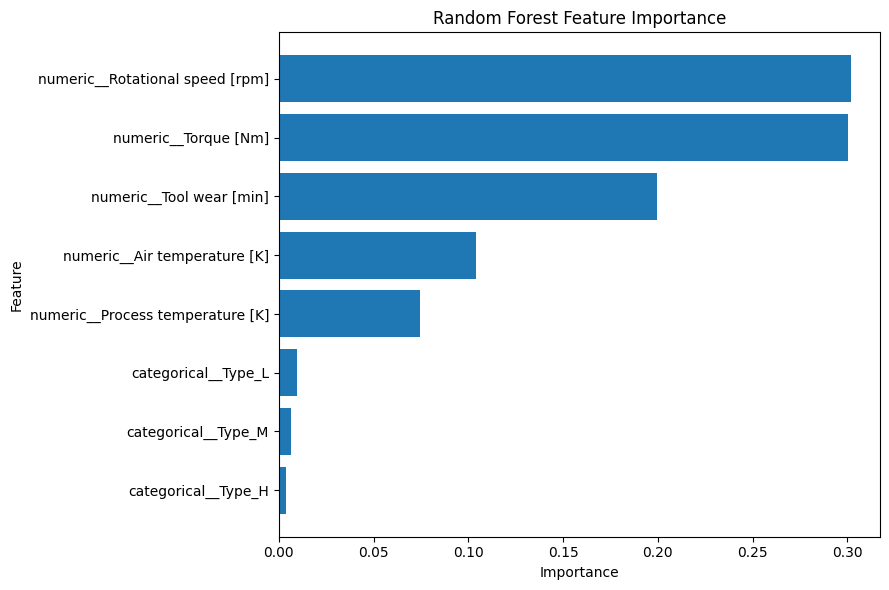

In [15]:
plt.figure(figsize=(9, 6))

plot_data = importance_df.sort_values(
    "Importance",
    ascending=True
)

plt.barh(
    plot_data["Feature"],
    plot_data["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [16]:
rf_model_pipeline = trained_models["Random Forest"]

test_probabilities = rf_model_pipeline.predict_proba(
    X_test
)[:, 1]

test_results = X_test.copy()

test_results["Actual Machine Failure"] = y_test.values
test_results["Estimated Failure Probability"] = test_probabilities

test_results = test_results.sort_values(
    "Estimated Failure Probability",
    ascending=False
)

test_results.head(20)

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type,Actual Machine Failure,Estimated Failure Probability
1391,298.9,310.2,2737,8.8,142,L,1,0.876667
4661,303.3,311.3,1350,48.1,32,L,1,0.816667
4495,302.6,310.4,1359,57.2,67,L,1,0.806667
380,297.5,308.3,2564,12.8,127,L,1,0.780000
7997,301.0,312.2,2710,9.7,143,M,1,0.776667
6078,300.8,310.7,1339,59.1,203,L,1,0.770000
7011,300.5,310.5,2633,12.2,17,L,1,0.766667
9664,299.1,310.2,1317,54.8,231,L,1,0.746667
248,298.0,308.3,1362,56.8,216,L,1,0.743333
2444,299.2,308.6,1267,68.2,76,L,1,0.706667


In [17]:
def preliminary_risk_band(probability):

    if probability >= 0.75:
        return "Very High"

    elif probability >= 0.50:
        return "High"

    elif probability >= 0.25:
        return "Moderate"

    elif probability >= 0.10:
        return "Elevated"

    else:
        return "Low"


test_results["Preliminary Risk Band"] = (
    test_results["Estimated Failure Probability"]
    .apply(preliminary_risk_band)
)

test_results[
    [
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Actual Machine Failure",
        "Estimated Failure Probability",
        "Preliminary Risk Band"
    ]
].head(25)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Actual Machine Failure,Estimated Failure Probability,Preliminary Risk Band
1391,L,298.9,310.2,2737,8.8,142,1,0.876667,Very High
4661,L,303.3,311.3,1350,48.1,32,1,0.816667,Very High
4495,L,302.6,310.4,1359,57.2,67,1,0.806667,Very High
380,L,297.5,308.3,2564,12.8,127,1,0.780000,Very High
7997,M,301.0,312.2,2710,9.7,143,1,0.776667,Very High
6078,L,300.8,310.7,1339,59.1,203,1,0.770000,Very High
7011,L,300.5,310.5,2633,12.2,17,1,0.766667,Very High
9664,L,299.1,310.2,1317,54.8,231,1,0.746667,High
248,L,298.0,308.3,1362,56.8,216,1,0.743333,High
2444,L,299.2,308.6,1267,68.2,76,1,0.706667,High


### Important Note on Risk Bands

The probability bands shown above are preliminary demonstration categories created for the proof-of-concept.

They are not industry standards, regulatory thresholds, or validated maintenance action limits.

Their present purpose is only to demonstrate how continuous model probabilities could later be translated into understandable categories within a decision-support interface.

Final thresholds would require validation against appropriate facility data, operational consequences, engineering requirements, and user needs.

In [18]:
formatted_results.to_csv(
    "/content/model_metrics.csv",
    index=False
)

cv_results_df.to_csv(
    "/content/cross_validation_metrics.csv",
    index=False
)

test_results.to_csv(
    "/content/test_failure_risk_predictions.csv",
    index=False
)

importance_df.to_csv(
    "/content/random_forest_feature_importance.csv",
    index=False
)

print("Result files created successfully.")

Result files created successfully.


## Preliminary Modeling Conclusions

This stage established a reproducible baseline failure risk modeling pipeline using the AI4I 2020 Predictive Maintenance Dataset.

The analysis compared a majority class baseline with logistic regression, decision tree, and random forest classification methods. Model evaluation included ordinary accuracy, balanced accuracy, precision, recall, F1 score, ROC-AUC, average precision, confusion matrices, and precision-recall behavior.

Stratified cross validation was also performed to examine whether model performance remained reasonably consistent across different partitions of the training data.

The individual failure mode variables were excluded from model inputs to reduce the risk of target leakage. Identifier variables were also excluded from the predictor set.

The models also produced estimated failure probabilities that can serve as an input to the later maintenance prioritization component of the framework.

The results remain preliminary. Model performance on this synthetic dataset does not establish validity for actual industrial equipment, and no model is presently being represented as suitable for operational maintenance decisions.

The next development stage will examine how failure risk estimates can be combined with equipment criticality, operational consequence, downtime, maintenance cost, and resource constraints in a transparent maintenance prioritization proof-of-concept.